In [7]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import matplotlib.pyplot as plt

In [21]:
STARTING_BALANCE=10000
PERIODS=[50,200]

In [11]:
START=datetime.datetime(2005,1,1)
END=datetime.datetime(2015,1,1)
YEARS=(END-START).days/365.25

In [12]:
price=yf.download('^GSPC',START,END)
price.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2005-01-03,1202.079956,1217.800049,1200.319946,1211.920044,1510800000
2005-01-04,1188.050049,1205.839966,1185.390015,1202.079956,1721000000
2005-01-05,1183.739990,1192.729980,1183.719971,1188.050049,1738900000
2005-01-06,1187.890015,1191.630005,1183.270020,1183.739990,1569100000
2005-01-07,1186.189941,1192.199951,1182.160034,1187.890015,1477900000


In [13]:
price.drop(['High','Low','Volume'],axis=1,inplace=True)
price.head()

Price,Close,Open
Ticker,^GSPC,^GSPC
Date,,
2005-01-03,1202.079956,1211.920044
2005-01-04,1188.050049,1202.079956
2005-01-05,1183.739990,1188.050049
2005-01-06,1187.890015,1183.739990
2005-01-07,1186.189941,1187.890015


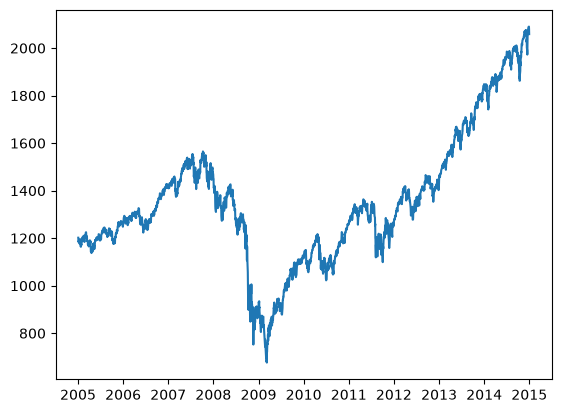

In [14]:
plt.plot(price['Close'])
plt.show()

In [15]:
price['Return']=price['Close']/price['Open']
price['Bench_Bal']=STARTING_BALANCE*price['Return'].cumprod()

In [16]:
price.tail()

Price,Close,Open,Return,Bench_Bal
Ticker,^GSPC,^GSPC,,
Date,,,,
2014-12-24,2081.879883,2083.250000,0.999342,18430.344448
2014-12-26,2088.770020,2084.300049,1.002145,18469.869995
2014-12-29,2090.570068,2087.629883,1.001408,18495.882673
2014-12-30,2080.350098,2088.489990,0.996102,18423.794945
2014-12-31,2058.899902,2082.110107,0.988853,18218.416729


In [18]:
bench_return=round(((price['Bench_Bal'].iloc[-1]/price['Bench_Bal'].iloc[0])-1)*100,2)
bench_cagr=round((((price['Bench_Bal'].iloc[-1]/price['Bench_Bal'].iloc[0])**(1/YEARS))-1)*100,2)

print(bench_return)
print(bench_cagr)

83.68
6.27


In [19]:
price['Bench_Peak']=price['Bench_Bal'].cummax()
price['Bench_DD']=price['Bench_Bal']-price['Bench_Peak']
bench_dd=round((((price['Bench_DD']/price['Bench_Peak']).min())*100),2)
print(bench_dd)

-52.29


In [22]:
price['Fast_MA']=price['Close'].rolling(window=PERIODS[0]).mean()
price['Slow_MA']=price['Close'].rolling(window=PERIODS[1]).mean()
price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA
Ticker,^GSPC,^GSPC,,,,,,
Date,,,,,,,,
2014-12-24,2081.879883,2083.250000,0.999342,18430.344448,18442.473741,-12.129293,2019.272600,1953.167598
2014-12-26,2088.770020,2084.300049,1.002145,18469.869995,18469.869995,0.000000,2023.798201,1954.379748
2014-12-29,2090.570068,2087.629883,1.001408,18495.882673,18495.882673,0.000000,2028.354402,1955.626948
2014-12-30,2080.350098,2088.489990,0.996102,18423.794945,18495.882673,-72.087728,2032.226204,1956.734549
2014-12-31,2058.899902,2082.110107,0.988853,18218.416729,18495.882673,-277.465944,2035.324001,1957.667798


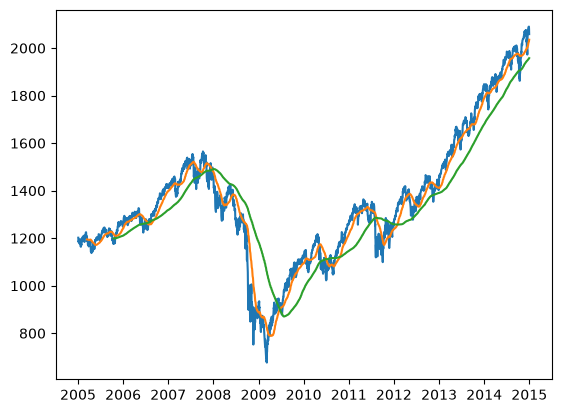

In [24]:
plt.plot(price['Close'])
plt.plot(price['Fast_MA'])
plt.plot(price['Slow_MA'])
plt.show()

In [25]:
price['long']=price['Fast_MA']>price['Slow_MA']

price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA,long
Ticker,^GSPC,^GSPC,,,,,,,
Date,,,,,,,,,
2014-12-24,2081.879883,2083.250000,0.999342,18430.344448,18442.473741,-12.129293,2019.272600,1953.167598,True
2014-12-26,2088.770020,2084.300049,1.002145,18469.869995,18469.869995,0.000000,2023.798201,1954.379748,True
2014-12-29,2090.570068,2087.629883,1.001408,18495.882673,18495.882673,0.000000,2028.354402,1955.626948,True
2014-12-30,2080.350098,2088.489990,0.996102,18423.794945,18495.882673,-72.087728,2032.226204,1956.734549,True
2014-12-31,2058.899902,2082.110107,0.988853,18218.416729,18495.882673,-277.465944,2035.324001,1957.667798,True


In [28]:
price['Sys_Return']=np.where(price['long'].shift(1)==True,price['Return'],1)
price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA,long,Sys_Bal,Sys_Return
Ticker,^GSPC,^GSPC,,,,,,,,,
Date,,,,,,,,,,,
2014-12-24,2081.879883,2083.250000,0.999342,18430.344448,18442.473741,-12.129293,2019.272600,1953.167598,True,0.999342,0.999342
2014-12-26,2088.770020,2084.300049,1.002145,18469.869995,18469.869995,0.000000,2023.798201,1954.379748,True,1.002145,1.002145
2014-12-29,2090.570068,2087.629883,1.001408,18495.882673,18495.882673,0.000000,2028.354402,1955.626948,True,1.001408,1.001408
2014-12-30,2080.350098,2088.489990,0.996102,18423.794945,18495.882673,-72.087728,2032.226204,1956.734549,True,0.996102,0.996102
2014-12-31,2058.899902,2082.110107,0.988853,18218.416729,18495.882673,-277.465944,2035.324001,1957.667798,True,0.988853,0.988853


In [29]:
price['Sys_Bal']=STARTING_BALANCE*price['Sys_Return'].cumprod()
price.tail()

Price,Close,Open,Return,Bench_Bal,Bench_Peak,Bench_DD,Fast_MA,Slow_MA,long,Sys_Bal,Sys_Return
Ticker,^GSPC,^GSPC,,,,,,,,,
Date,,,,,,,,,,,
2014-12-24,2081.879883,2083.250000,0.999342,18430.344448,18442.473741,-12.129293,2019.272600,1953.167598,True,20681.124605,0.999342
2014-12-26,2088.770020,2084.300049,1.002145,18469.869995,18469.869995,0.000000,2023.798201,1954.379748,True,20725.477154,1.002145
2014-12-29,2090.570068,2087.629883,1.001408,18495.882673,18495.882673,0.000000,2028.354402,1955.626948,True,20754.666595,1.001408
2014-12-30,2080.350098,2088.489990,0.996102,18423.794945,18495.882673,-72.087728,2032.226204,1956.734549,True,20673.775254,0.996102
2014-12-31,2058.899902,2082.110107,0.988853,18218.416729,18495.882673,-277.465944,2035.324001,1957.667798,True,20443.315509,0.988853


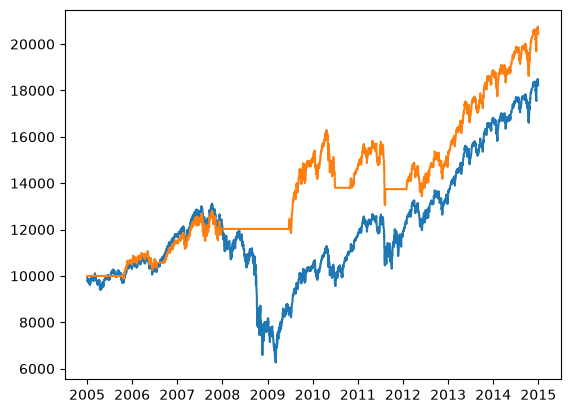

In [31]:
plt.plot(price['Bench_Bal'])
plt.plot(price['Sys_Bal'])
plt.show()

In [34]:
sys_return= round(((price['Sys_Bal'].iloc[-1]/price['Sys_Bal'].iloc[0])-1)*100,2)
sys_cagr= round((((price['Sys_Bal'].iloc[-1]/price['Sys_Bal'].iloc[0])**(1/YEARS))-1)*100,2)
print(sys_return)
print(sys_cagr)

104.43
7.41


In [36]:
price['Sys_Peak']=price['Sys_Bal'].cummax()
price['Sys_DD']=price['Sys_Bal']-price['Sys_Peak']
sys_dd=round(((price['Sys_DD']/price['Sys_Peak']).min())*100,2)
print(sys_dd)

-19.86


In [37]:
print(f"Benchmark total return: {bench_return}%")
print(f"Benchmark total cagr: {bench_cagr}")
print(f"Benchmark DD: {bench_dd}%")
print("")
print(f"Sytem Return: {sys_return}%")
print(f"System cagr: {sys_cagr}")
print(f"Sytem DD: {sys_dd}%")

Benchmark total return: 83.68%
Benchmark total cagr: 6.27
Benchmark DD: -52.29%

Sytem Return: 104.43%
System cagr: 7.41
Sytem DD: -19.86%
